<a href="https://colab.research.google.com/github/CarlosGuimaraes28/Meu-Bi-Financas/blob/main/meu_bi_financeiro_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Meu B.I. Financeiro

Este projeto, desenvolvido no âmbito da disciplina de Tópicos de Big Data em Python com o professor Rafael Araújo.

----
# Motivação do Tema:

A escolha do tema foi motivada pela observação, em um contexto profissional na fintech PagBank, da necessidade recorrente de usuários por ferramentas que auxiliem na compreensão e gestão de suas transações financeiras. Frequentemente, a ausência de uma visualização clara dos padrões de gastos representa um obstáculo para um planejamento financeiro eficaz.

----
# Metodologia:

A solução proposta consiste em um script em Python que utiliza bibliotecas de Data Science, como Pandas, Matplotlib e Scikit-learn, para processar, categorizar e visualizar dados financeiros.

-----
# Objetivo

O sistema foi projetado para permitir que o usuário importe extratos bancários em formato CSV ou insira transações manualmente, gerando, ao final, análises visuais detalhadas e uma previsão de gastos baseada em regressão linear.



*Configuração fundamental do ambiente de execução do projeto*

**Importação de Bibliotecas:** São carregadas todas as bibliotecas externas necessárias para a manipulação de dados, visualização e modelagem. Destacam-se: Pandas para a estruturação dos dados em DataFrames; Matplotlib e Seaborn para a geração dos gráficos; e Scikit-learn para a implementação do modelo de aprendizado de máquina.


**Definição de Funções Modulares:** Para promover a organização e a reutilização de código, a lógica principal de interação e classificação é encapsulada em funções. A função adicionar_transacao_manual gerencia a interface de entrada de dados do usuário, enquanto a função categorizar_transacao contém o algoritmo para classificar as transações com base em suas descrições.

In [ ]:
# ===================================================================
# SETUP E FUNÇÕES
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import os
from google.colab import files # Para upload de arquivos
import io
from datetime import date

# Configurações para os gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# --- FUNÇÃO PARA ADICIONAR RECEITAS E DESPESAS MANUALMENTE ---
def adicionar_transacao_manual(dataframe_existente):
    """Pede dados ao usuário e adiciona uma nova transação a um DataFrame."""
    print("\n--- Adicionando Nova Transação ---")
    tipo = input("Digite o tipo: (1) Receita ou (2) Despesa: ")
    while tipo not in ['1', '2']:
        tipo = input("Opção inválida. Digite (1) Receita ou (2) Despesa: ")

    descricao = input("Digite a descrição da transação: ")
    while True:
        try:
            valor_str = input("Digite o valor (ex: 50.75): ")
            valor = float(valor_str)
            break
        except ValueError:
            print("Valor inválido. Use apenas números e ponto.")

    valor = abs(valor) if tipo == '1' else -abs(valor)
    data_hoje = pd.to_datetime(date.today())

    nova_linha = pd.DataFrame({
        'Data': [data_hoje],
        'Descricao': [descricao],
        'Valor': [valor]
    })

    df_atualizado = pd.concat([dataframe_existente, nova_linha], ignore_index=True)
    print("✅ Transação adicionada com sucesso!")
    return df_atualizado

# --- FUNÇÃO PARA CATEGORIZAR TRANSAÇÕES ---
def categorizar_transacao(descricao):
    """Categoriza uma transação baseada na sua descrição."""
    if not isinstance(descricao, str):
        return 'Outros' # Retorna um padrão caso a descrição não seja um texto

    descricao = descricao.lower()
    if 'salario' in descricao: return 'Receita'
    if any(keyword in descricao for keyword in ['supermercado', 'feira', 'ifood', 'restaurante']): return 'Alimentação'
    if any(keyword in descricao for keyword in ['uber', 'gasolina', '99']): return 'Transporte'
    if any(keyword in descricao for keyword in ['aluguel', 'luz', 'agua', 'condominio']): return 'Moradia'
    if 'farmacia' in descricao: return 'Saúde'
    if any(keyword in descricao for keyword in ['cinema', 'show', 'netflix', 'amazon', 'spotify','xbox']): return 'Lazer'
    if 'academia' in descricao: return 'Cuidados Pessoais'
    return 'Outros'

*Ingestão de dados*

O script apresenta ao usuário um menu com duas opções de entrada:

1 - **Carregamento de Arquivo CSV:** Este método permite ao usuário realizar o upload de um extrato bancário ou outro arquivo de dados em formato CSV. É a opção ideal para a análise de um grande volume de transações históricas de forma eficiente.

2 - **Inserção Manual de Dados:** Este método oferece uma interface de linha de comando para o registro de transações individuais. Os dados inseridos são salvos em um arquivo CSV local (extrato_manual.csv), garantindo a persistência dos dados entre sessões de uso.

Resultado: um DataFrame padronizado é gerado, servindo como a fonte de dados unificada para o módulo de análise, independentemente do método de entrada escolhido pelo usuário.

In [ ]:
# ===================================================================
# MENU PRINCIPAL E ENTRADA DE DADOS
# ===================================================================

# Define o nome do arquivo padrão para entradas manuais
nome_arquivo_manual = 'extrato_manual.csv'
df = pd.DataFrame() # Inicia o DataFrame vazio

print("Bem-vindo ao Analisador de Despesas Pessoais!")
print("="*45)

# --- Menu de Escolha ---
while True:
    escolha = input("Como você deseja inserir os dados?\n (1) Carregar um arquivo CSV\n (2) Inserir dados manualmente\nDigite sua escolha: ")
    if escolha in ['1', '2']:
        break
    print("Opção inválida. Tente novamente.")

# --- Opção 1: Upload de CSV ---
if escolha == '1':
    print("\nPor favor, selecione o seu arquivo CSV.")
    uploaded = files.upload()

    if not uploaded:
        print("\nNenhum arquivo foi selecionado. O programa será encerrado.")
    else:
        nome_arquivo_upado = list(uploaded.keys())[0]
        print(f"\nArquivo '{nome_arquivo_upado}' carregado com sucesso!")
        df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo_upado]))
        print("IMPORTANTE: Verifique se as colunas do seu arquivo são 'Data', 'Descricao' e 'Valor'.")
        print("Se os nomes forem diferentes (ex: 'Histórico'), você precisará renomeá-los.")

# --- Opção 2: Inserção Manual ---
elif escolha == '2':
    df_manual = pd.DataFrame(columns=['Data', 'Descricao', 'Valor'])
    if os.path.exists(nome_arquivo_manual):
        print(f"\nEncontrei um arquivo salvo ('{nome_arquivo_manual}').")
        carregar = input("Deseja carregar os dados salvos e adicionar novos? (s/n): ").lower()
        if carregar == 's':
            df_manual = pd.read_csv(nome_arquivo_manual)

    while True:
        df_manual = adicionar_transacao_manual(df_manual)
        continuar = input("\nDeseja adicionar outra transação? (s/n): ").lower()
        if continuar != 's':
            break

    df = df_manual
    df.to_csv(nome_arquivo_manual, index=False)
    print(f"\nTodos os dados foram salvos em '{nome_arquivo_manual}' para uso futuro.")

# --- Preparação Final do DataFrame (comum a ambas as opções) ---
if not df.empty:
    # Garante que a coluna de data esteja no formato correto
    try:
        df['Data'] = pd.to_datetime(df['Data'])
    except Exception as e:
        print(f"Aviso: Não foi possível converter a coluna 'Data' automaticamente. Erro: {e}")
        print("A análise temporal pode não funcionar corretamente.")

    print("\n--- Tabela de Dados Pronta para Análise ---")
    print(df.head())
else:
    print("\nO DataFrame está vazio. Não há dados para analisar.")

Bem-vindo ao Analisador de Despesas Pessoais!
Como você deseja inserir os dados?
 (1) Carregar um arquivo CSV
 (2) Inserir dados manualmente
Digite sua escolha: 2

--- Adicionando Nova Transação ---
Digite o tipo: (1) Receita ou (2) Despesa: 2
Digite a descrição da transação: game pass
Digite o valor (ex: 50.75): 120


/tmp/ipython-input-1497986666.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_atualizado = pd.concat([dataframe_existente, nova_linha], ignore_index=True)


✅ Transação adicionada com sucesso!

Deseja adicionar outra transação? (s/n): s

--- Adicionando Nova Transação ---
Digite o tipo: (1) Receita ou (2) Despesa: 1
Digite a descrição da transação: recebimento de aluguel
Digite o valor (ex: 50.75): 1000
✅ Transação adicionada com sucesso!

Deseja adicionar outra transação? (s/n): n

Todos os dados foram salvos em 'extrato_manual.csv' para uso futuro.

--- Tabela de Dados Pronta para Análise ---
        Data               Descricao   Valor
0 2025-10-05               game pass  -120.0
1 2025-10-05  recebimento de aluguel  1000.0


*Processamento e a análise do DataFrame gerado na etapa anterior*

O objetivo é transformar os dados brutos em informações visuais e preditivas que agreguem valor à compreensão financeira do usuário.

----------------------------------------------------------------------------

O processo é dividido em três etapas principais:

1 - *Categorização Automática:* A função categorizar_transacao é aplicada ao conjunto de dados para atribuir a cada transação uma categoria financeira correspondente (ex: Alimentação, Moradia), enriquecendo os dados para uma análise mais detalhada.

2 - *Geração de Visualizações:* São criados dois gráficos principais para a exploração dos dados: um gráfico de barras que ilustra o total de despesas por categoria, permitindo a identificação dos principais focos de gastos, e um gráfico de fluxo de caixa mensal, que compara a evolução de receitas e despesas ao longo do tempo.

3 - *Modelagem Preditiva:* Utilizando a biblioteca Scikit-learn, um modelo de regressão linear simples é treinado com base nos dados históricos de despesas mensais. O modelo é, então, empregado para gerar uma previsão de gastos para o período subsequente, demonstrando uma aplicação prática de aprendizado de máquina em finanças pessoais.


Gerando Gráficos...


/tmp/ipython-input-2755481935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gastos_por_categoria.index, y=gastos_por_categoria.values, palette='viridis')


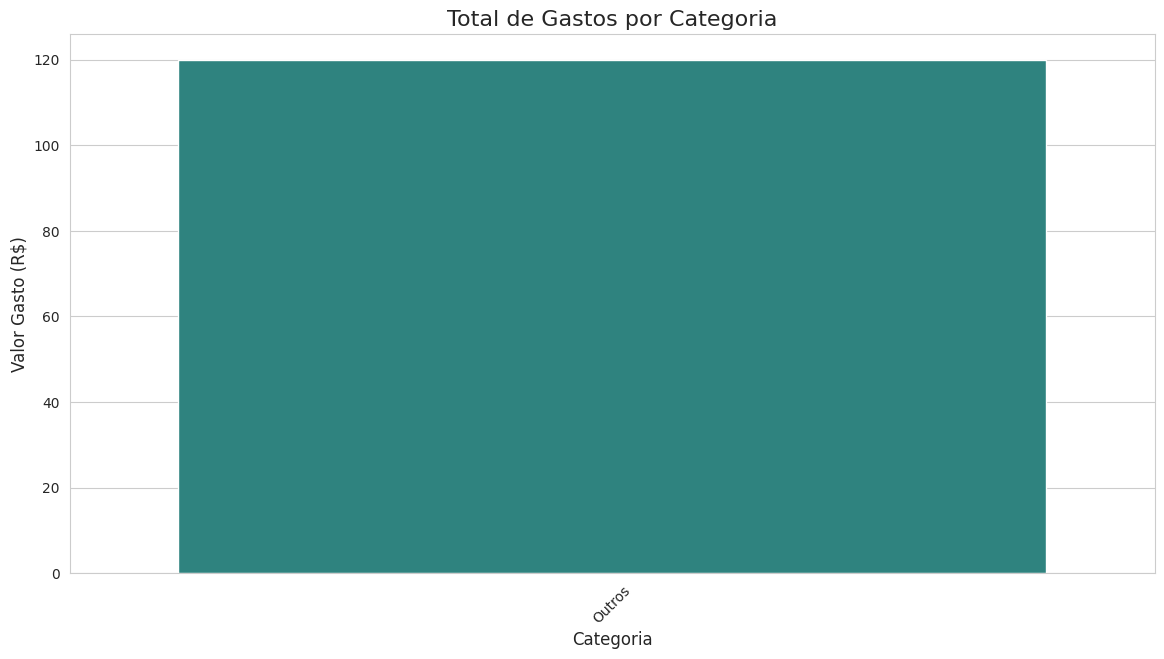

/tmp/ipython-input-2755481935.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  receitas_mensais = df_temporal[df_temporal['Valor'] > 0]['Valor'].resample('M').sum()
/tmp/ipython-input-2755481935.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  despesas_mensais = df_temporal[df_temporal['Valor'] < 0]['Valor'].abs().resample('M').sum()


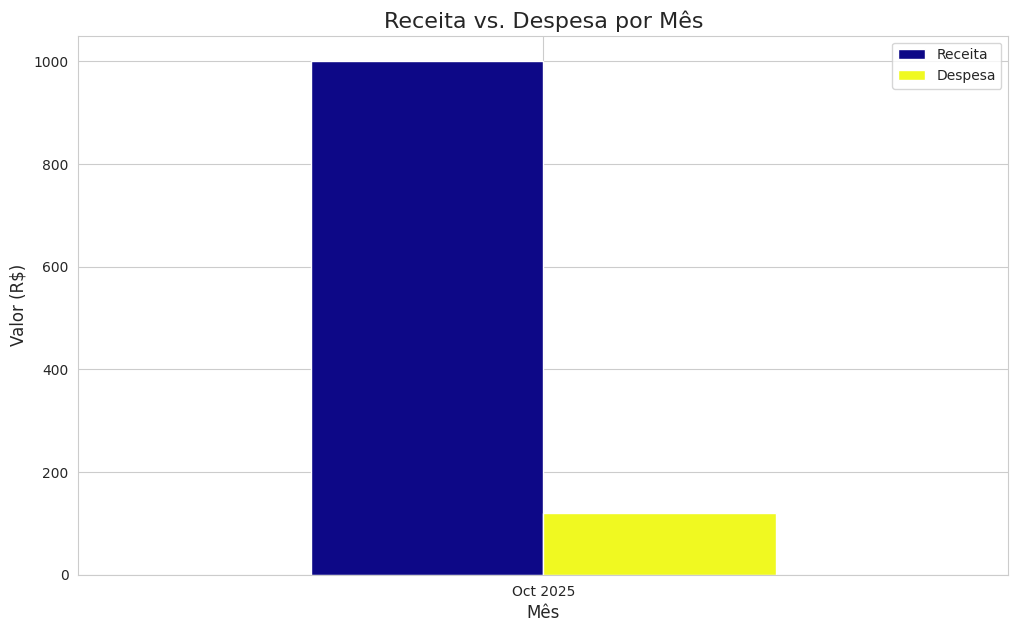


Não há dados mensais suficientes para realizar uma previsão de Machine Learning.


In [ ]:
# ===================================================================
# ANÁLISE, GRÁFICOS E MACHINE LEARNING
# ===================================================================

if not df.empty:
    # --- Passo 1: Aplicar a categorização ---
    df['Categoria'] = df['Descricao'].apply(categorizar_transacao)

    # --- Passo 2: Gerar Gráficos ---
    print("\nGerando Gráficos...")

    # Gráfico 1: Gastos por Categoria
    despesas = df[df['Valor'] < 0].copy()
    despesas['Valor'] = despesas['Valor'].abs()
    gastos_por_categoria = despesas.groupby('Categoria')['Valor'].sum().sort_values(ascending=False)

    if not gastos_por_categoria.empty:
        plt.figure(figsize=(14, 7))
        sns.barplot(x=gastos_por_categoria.index, y=gastos_por_categoria.values, palette='viridis')
        plt.title('Total de Gastos por Categoria', fontsize=16)
        plt.xlabel('Categoria', fontsize=12)
        plt.ylabel('Valor Gasto (R$)', fontsize=12)
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("\nNenhuma despesa registrada para gerar o gráfico de categorias.")

    # Gráfico 2: Fluxo de Caixa Mensal
    df_temporal = df.set_index('Data')
    receitas_mensais = df_temporal[df_temporal['Valor'] > 0]['Valor'].resample('M').sum()
    despesas_mensais = df_temporal[df_temporal['Valor'] < 0]['Valor'].abs().resample('M').sum()
    fluxo_caixa = pd.DataFrame({'Receita': receitas_mensais, 'Despesa': despesas_mensais}).fillna(0)

    if not fluxo_caixa.empty:
        fluxo_caixa.plot(kind='bar', figsize=(12, 7), colormap='plasma')
        plt.title('Receita vs. Despesa por Mês', fontsize=16)
        plt.xlabel('Mês', fontsize=12)
        plt.ylabel('Valor (R$)', fontsize=12)
        plt.xticks(ticks=range(len(fluxo_caixa.index)), labels=[d.strftime('%b %Y') for d in fluxo_caixa.index], rotation=0)
        plt.legend(['Receita', 'Despesa'])
        plt.show()
    else:
        print("\nNão há dados suficientes para gerar o gráfico de fluxo de caixa mensal.")

    # --- Machine Learning (se houver dados suficientes) ---
    if len(fluxo_caixa) > 2: # Precisa de pelo menos 3 pontos para uma regressão mínima
      print("\nRealizando previsão de gastos com Machine Learning...")
      dados_previsao = despesas_mensais.reset_index()
      dados_previsao.columns = ['Data', 'Total_Gasto']
      dados_previsao['Mes_Num'] = range(1, len(dados_previsao) + 1)

      X = dados_previsao[['Mes_Num']]
      y = dados_previsao['Total_Gasto']

      model = LinearRegression()
      model.fit(X, y)

      proximo_mes = [[len(dados_previsao) + 1]]
      previsao_gasto = model.predict(proximo_mes)
      print(f"Previsão de gasto para o próximo mês: R$ {previsao_gasto[0]:.2f}")
    else:
      print("\nNão há dados mensais suficientes para realizar uma previsão de Machine Learning.")

else:
    print("\nExecução finalizada. Nenhum dado foi processado.")

----
## Melhorias adicionadas v2
Estrutura e organização

O código foi reorganizado em partes mais claras, com títulos e explicações em cada etapa. Isso facilita entender o que cada célula faz e seguir a sequência correta de execução.

Limpeza e tratamento de dados

Foi criada uma função que faz automaticamente a limpeza e padronização dos dados. Ela identifica as colunas de data, valor, descrição e categoria, mesmo que tenham nomes diferentes, e converte os formatos corretamente. Também elimina linhas com erros e organiza as informações por data.

Análises e gráficos

Agora o notebook gera um resumo automático com o saldo total, receitas e despesas, além de um gráfico mostrando a evolução mensal dos valores. Isso ajuda a visualizar o comportamento financeiro de forma rápida.

Previsão de gastos

Foi adicionada uma função que faz uma previsão simples dos gastos futuros com base nos meses anteriores. Essa previsão usa um modelo de regressão linear e serve como uma estimativa das tendências.

Exportação

Também foi incluída uma função para salvar os dados atualizados em um novo arquivo CSV, permitindo guardar o resultado final depois das análises.
----


In [ ]:
# Função: limpeza e normalização rápida (v2)
def normalizar_e_limpar(df):
    df = df.copy()
    # converte datas quando possível
    for col in df.columns:
        if 'date' in col.lower() or 'data' in col.lower():
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
            except:
                pass
    # tentativas de detectar coluna de valor
    if 'amount' not in df.columns:
        for c in df.columns:
            if any(x in c.lower() for x in ['valor','amount','vlr']):
                df = df.rename(columns={c:'amount'})
                break
    if 'amount' in df.columns:
        df['amount'] = df['amount'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
    # detectar coluna de data
    if 'date' not in df.columns:
        for c in df.columns:
            if 'date' in c.lower() or 'data' in c.lower():
                df = df.rename(columns={c:'date'})
                break
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    # preencher categorias
    if 'category' not in df.columns:
        df['category'] = 'Sem Categoria'
    df['category'] = df['category'].fillna('Sem Categoria')
    # descrição
    if 'description' not in df.columns:
        df['description'] = ''
    df['description'] = df['description'].fillna('')
    df = df.dropna(subset=['date','amount'], how='any')
    df = df.sort_values('date').reset_index(drop=True)
    return df


In [ ]:
# Função: resumo e gráficos (v2)
def relatorio_rapido(df):
    print('Linhas:', len(df))
    print('Período:', df['date'].min(), 'até', df['date'].max())
    total = df['amount'].sum()
    print('Saldo total:', total)
    receitas = df[df['amount']>0]['amount'].sum()
    despesas = df[df['amount']<0]['amount'].sum()
    print('Receitas:', receitas, 'Despesas:', despesas)
    # gráfico saldo mensal
    dfm = df.groupby(df['date'].dt.to_period('M'))['amount'].sum().reset_index()
    dfm['date'] = dfm['date'].dt.to_timestamp()
    plt.figure()
    plt.plot(dfm['date'], dfm['amount'], marker='o')
    plt.title('Saldo mensal')
    plt.grid(True)
    plt.show()


In [ ]:
# Função: prever gastos (adicionada)
def prever_gastos(df, meses_a_frente=1):
    dfm = df.groupby(df['date'].dt.to_period('M'))['amount'].sum().reset_index()
    dfm['month_idx'] = np.arange(len(dfm))
    X = dfm[['month_idx']].values
    y = dfm['amount'].values
    if len(X) < 3:
        print('Dados insuficientes para previsão (necessário pelo menos 3 meses).')
        return None, None
    model = LinearRegression()
    model.fit(X, y)
    future_idx = np.array([[dfm['month_idx'].max() + meses_a_frente]])
    pred = model.predict(future_idx)[0]
    print(f'Previsão para {meses_a_frente} mês(es) à frente: {pred:.2f}')
    return pred, model
